<a href="https://colab.research.google.com/github/RafaXzaviero/BENGKEL-KODING/blob/main/BENGKOD_ProjectJalurCepat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Latar Belakang**

Depresi pada mahasiswa merupakan salah satu masalah kesehatan mental yang
semakin meningkat di berbagai negara. Tekanan akademik, tuntutan sosial, serta
faktor gaya hidup dapat mempengaruhi kondisi psikologis mahasiswa. Jika tidak
ditangani dengan baik, depresi dapat berdampak pada penurunan performa akademik,
kualitas hidup, bahkan risiko putus studi. Oleh karena itu, kemampuan untuk
mendeteksi kondisi depresi sejak dini menjadi sangat penting.
Dataset Student Depression berisi informasi terkait kondisi mahasiswa, seperti faktor
akademik, gaya hidup, kebiasaan sehari-hari, serta kondisi mental. Dataset ini
memiliki variabel target berupa Status Depresi yang bersifat biner, yaitu Ya dan Tidak.
Dalam proyek ini, Anda berperan sebagai seorang Data Scientist yang bertugas untuk
menganalisis dataset serta membangun model machine learning guna memprediksi
status depresi mahasiswa, serta melakukan evaluasi terhadap model yang dibangun.

In [4]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv ('/content/Bengkod-Depresi.csv')

In [6]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1.0
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0.0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0.0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1.0
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0.0


In [7]:
df.tail()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
28003,103,Female,19,Kalyan,Student,5,0,5.64,5,0,Less than 5 hours,Moderate,Class 12,Yes,4,5.0,Yes,1.0
28004,106,Male,29,Srinagar,Student,3,0,8.58,3,0,More than 8 hours,Moderate,M.Tech,Yes,10,2.0,Yes,1.0
28005,120,Male,25,Nashik,Student,5,0,6.51,2,0,Less than 5 hours,Unhealthy,M.Ed,Yes,2,5.0,Yes,1.0
28006,132,Female,20,Ahmedabad,Student,5,0,7.25,3,0,5-6 hours,Healthy,Class 12,Yes,10,3.0,No,1.0
28007,139,Male,19,Chennai,Student,2,0,7.83,2,0,7-8 hours,Unhealthy,Class 12,No,6,3.0,No,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28008 entries, 0 to 28007
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     28008 non-null  int64  
 1   Gender                                 28008 non-null  object 
 2   Age                                    28008 non-null  int64  
 3   City                                   28008 non-null  object 
 4   Profession                             28008 non-null  object 
 5   Academic Pressure                      28008 non-null  int64  
 6   Work Pressure                          28008 non-null  int64  
 7   CGPA                                   28008 non-null  float64
 8   Study Satisfaction                     28008 non-null  int64  
 9   Job Satisfaction                       28008 non-null  int64  
 10  Sleep Duration                         28008 non-null  object 
 11  Di

In [9]:
df.shape

(28008, 18)

In [10]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,27963.000000,27966.000000
mean,70613.609933,25.824264,3.141245,0.000428,7.655372,2.944337,0.000678,7.154456,3.139077,0.585354
std,40792.430225,4.903456,1.380940,0.043908,1.470506,1.361318,0.044310,3.708348,1.437839,0.492670
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35075.500000,21.000000,2.000000,0.000000,6.287500,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70855.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,106075.750000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,141248.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


### 1. Exploratory Data Analysis (EDA)
This section, we identify data characteristics, handle quality issues, and extract insights regarding the target variable `Depression`.

Missing values per column:


,0
Financial Stress,45
Family History of Mental Illness,42
Depression,42


/tmp/ipykernel_2660/3213128176.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Depression', data=df, palette='viridis')


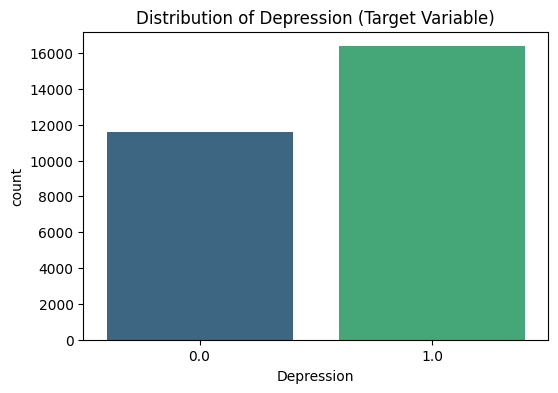

In [11]:
# Checking for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0])

# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Depression', data=df, palette='viridis')
plt.title('Distribution of Depression (Target Variable)')
plt.show()

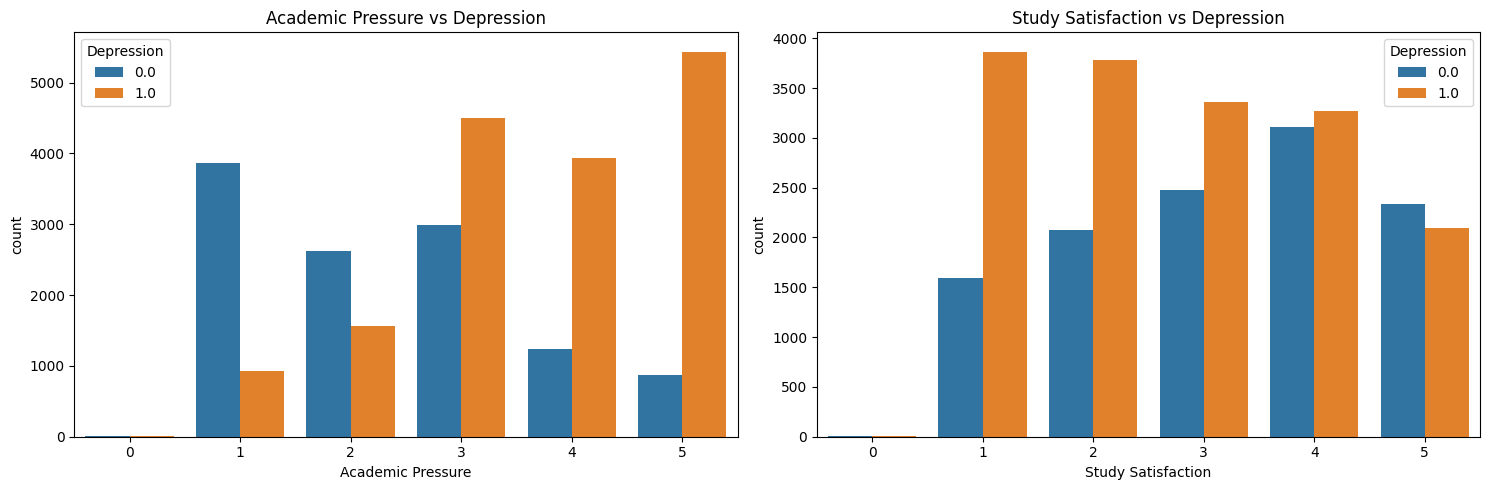

In [12]:
# Visualizing key categorical relationships with Depression
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(x='Academic Pressure', hue='Depression', data=df, ax=axes[0])
axes[0].set_title('Academic Pressure vs Depression')

sns.countplot(x='Study Satisfaction', hue='Depression', data=df, ax=axes[1])
axes[1].set_title('Study Satisfaction vs Depression')

plt.tight_layout()
plt.show()

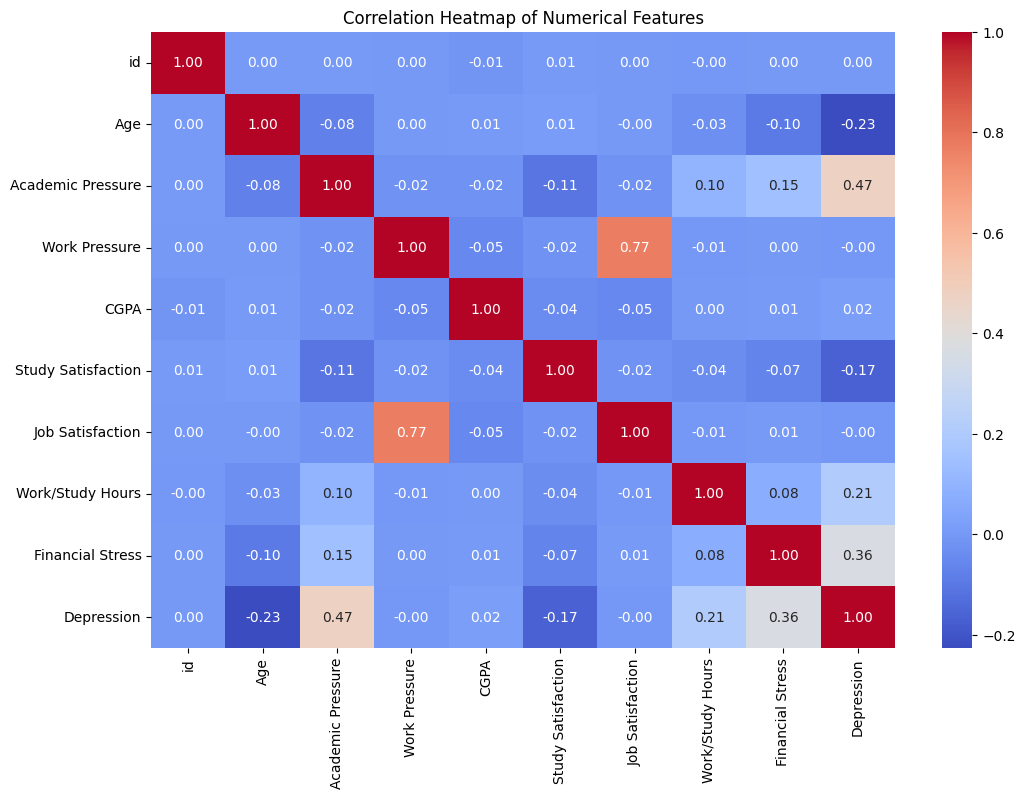

In [13]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 2. Direct Modeling
Before performing intensive preprocessing, Build 5 models to establish a performance baseline. This 'control group' helps us verify the effectiveness of cleaning and feature engineering later.

**Reasons for choosing these models:**
1. **Logistic Regression**: A simple linear baseline for binary classification.
2. **Decision Tree**: Capable of capturing non-linear patterns in the data.
3. **Random Forest (Ensemble)**: Reduces variance and avoids overfitting by averaging multiple trees.
4. **Gradient Boosting (Ensemble)**: Focuses on reducing bias by building trees sequentially.
5. **AdaBoost (Ensemble)**: Adjusts weights of incorrectly classified instances to improve accuracy.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Basic handling to allow direct modeling
# We drop missing values and perform basic one-hot encoding for the baseline
df_direct = df.dropna().copy()

# Selecting relevant features and encoding
# Dropping 'id' and high-cardinality columns for the initial baseline
X_direct = df_direct.drop(columns=['id', 'City', 'Profession', 'Degree', 'Depression'])
X_direct = pd.get_dummies(X_direct, drop_first=True)
y_direct = df_direct['Depression']

X_train, X_test, y_train, y_test = train_test_split(X_direct, y_direct, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

# Training and Evaluation
print("Baseline Model Performance (Direct Modeling):\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

Baseline Model Performance (Direct Modeling):

Logistic Regression Accuracy: 0.8421
Decision Tree Accuracy: 0.7661
Random Forest Accuracy: 0.8341
Gradient Boosting Accuracy: 0.8427
AdaBoost Accuracy: 0.8436


### 3. Modeling with Preprocessing
In this stage, Clean the data properly by imputing missing values and encoding all categorical variables (including high-cardinality ones like City and Degree) to compare the performance against our baseline.

In [16]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Create a copy for preprocessing
df_prep = df.copy()

# 1. Handling Missing Values
# Impute categorical with mode
mode_imputer = SimpleImputer(strategy='most_frequent')
df_prep[['Family History of Mental Illness', 'Depression']] = mode_imputer.fit_transform(df_prep[['Family History of Mental Illness', 'Depression']])

# Impute numerical with median
median_imputer = SimpleImputer(strategy='median')
df_prep[['Financial Stress']] = median_imputer.fit_transform(df_prep[['Financial Stress']])

# 2. Encoding Categorical Variables
le = LabelEncoder()
cat_cols = ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

for col in cat_cols:
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))

# 3. Splitting Data
X_p = df_prep.drop(columns=['id', 'Depression'])
y_p = df_prep['Depression'].astype(int)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_p, y_p, test_size=0.2, random_state=42)

# 4. Scaling
scaler = StandardScaler()
X_train_p = scaler.fit_transform(X_train_p)
X_test_p = scaler.transform(X_test_p)

print("Preprocessing Complete. Re-running models...")

# Re-evaluating models
for name, model in models.items():
    model.fit(X_train_p, y_train_p)
    acc = accuracy_score(y_test_p, model.predict(X_test_p))
    print(f"{name} (with Preprocessing) Accuracy: {acc:.4f}")

Preprocessing Complete. Re-running models...
Logistic Regression (with Preprocessing) Accuracy: 0.8424
Decision Tree (with Preprocessing) Accuracy: 0.7637
Random Forest (with Preprocessing) Accuracy: 0.8360
Gradient Boosting (with Preprocessing) Accuracy: 0.8418
AdaBoost (with Preprocessing) Accuracy: 0.8372


### 4. Feature Selection
In this step, Identify the most important features to reduce model complexity and potentially improve accuracy. Use Random Forest's built-in feature importance attribute.

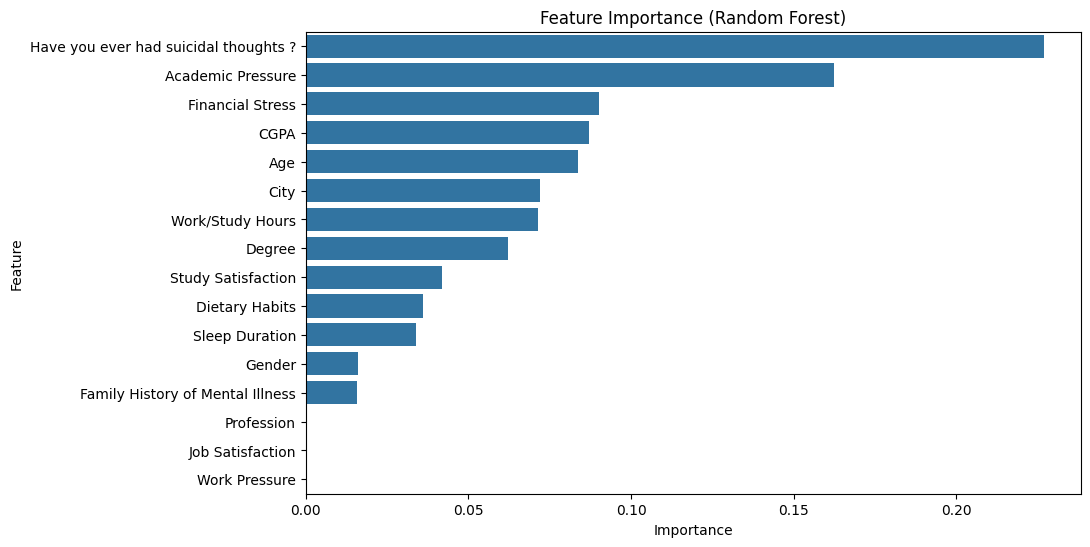

Selected Top Features: ['Have you ever had suicidal thoughts ?' 'Academic Pressure'
 'Financial Stress' 'CGPA' 'Age' 'City' 'Work/Study Hours' 'Degree'
 'Study Satisfaction' 'Dietary Habits']

Performance after Feature Selection:
Logistic Regression (Feature Selection) Accuracy: 0.8438
Decision Tree (Feature Selection) Accuracy: 0.7587
Random Forest (Feature Selection) Accuracy: 0.8311
Gradient Boosting (Feature Selection) Accuracy: 0.8409
AdaBoost (Feature Selection) Accuracy: 0.8401


In [17]:
# 1. Feature Importance using Random Forest
rf_model = models['Random Forest']
rf_model.fit(X_train_p, y_train_p)

importances = rf_model.feature_importances_
feature_names = X_p.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance (Random Forest)')
plt.show()

# 2. Select Top Features (e.g., top 10)
top_features = feature_importance_df['Feature'].head(10).values
print(f"Selected Top Features: {top_features}")

# 3. Retrain models using only selected features
X_train_fs = pd.DataFrame(X_train_p, columns=X_p.columns)[top_features]
X_test_fs = pd.DataFrame(X_test_p, columns=X_p.columns)[top_features]

print("\nPerformance after Feature Selection:")
for name, model in models.items():
    model.fit(X_train_fs, y_train_p)
    acc = accuracy_score(y_test_p, model.predict(X_test_fs))
    print(f"{name} (Feature Selection) Accuracy: {acc:.4f}")

### 5. Hyperparameter Tuning
Optimize the best-performing models from the previous steps using `GridSearchCV` to find the optimal parameters.

In [18]:
from sklearn.model_selection import GridSearchCV

# 1. Hyperparameter Tuning for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_fs, y_train_p)

print(f"Best Logistic Regression Params: {grid_lr.best_params_}")
print(f"Best Logistic Regression Score: {grid_lr.best_score_:.4f}")

# 2. Hyperparameter Tuning for Gradient Boosting
param_grid_gb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}

grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring='accuracy')
grid_gb.fit(X_train_fs, y_train_p)

print(f"Best Gradient Boosting Params: {grid_gb.best_params_}")
print(f"Best Gradient Boosting Score: {grid_gb.best_score_:.4f}")

# Save the best model for deployment
best_model = grid_lr.best_estimator_ if grid_lr.best_score_ > grid_gb.best_score_ else grid_gb.best_estimator_
print(f"\nFinal Selected Model for Deployment: {type(best_model).__name__}")

Best Logistic Regression Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best Logistic Regression Score: 0.8465
Best Gradient Boosting Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Best Gradient Boosting Score: 0.8470

Final Selected Model for Deployment: GradientBoostingClassifier


### 6. Preparing for Deployment
Save the final model, scaler, and the list of top features to a file using `joblib`. These files will be used in the Streamlit application to ensure that input data is preprocessed exactly like the training data.

In [19]:
import joblib

# Save the best model
joblib.dump(best_model, 'best_depression_model.joblib')

# Save the scaler
joblib.dump(scaler, 'scaler.joblib')

# Save the top feature names to ensure consistent input order in Streamlit
joblib.dump(top_features, 'top_features.joblib')

print("Model and preprocessing objects saved successfully!")

Model and preprocessing objects saved successfully!


### 7. Deployment Files Generation
This section generates the `app.py` and `requirements.txt` files required for Streamlit Cloud deployment.

In [20]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np

# Load artifacts
model = joblib.load('best_depression_model.joblib')
scaler = joblib.load('scaler.joblib')
top_features = joblib.load('top_features.joblib')

st.title("Student Depression Prediction App")
st.write("Aplikasi ini memprediksi status depresi mahasiswa berdasarkan faktor akademik dan gaya hidup.")

# Form for user input
with st.form("prediction_form"):
    st.subheader("Input Data Mahasiswa")

    # Dynamic inputs based on top features used in the model
    inputs = {}
    inputs['Have you ever had suicidal thoughts ?'] = st.selectbox("Pernah terpikir untuk bunuh diri?", ["No", "Yes"])
    inputs['Academic Pressure'] = st.slider("Tekanan Akademik (1-5)", 1, 5, 3)
    inputs['Financial Stress'] = st.slider("Tekanan Finansial (1-5)", 1, 5, 3)
    inputs['CGPA'] = st.number_input("CGPA", 0.0, 10.0, 7.5)
    inputs['Age'] = st.number_input("Usia", 18, 60, 21)
    inputs['City'] = st.text_input("Kota (Contoh: Srinagar, Jaipur)", "Srinagar")
    inputs['Work/Study Hours'] = st.number_input("Jam Belajar/Kerja per Hari", 1, 12, 6)
    inputs['Degree'] = st.text_input("Gelar (Contoh: B.Tech, BSc)", "B.Tech")
    inputs['Study Satisfaction'] = st.slider("Kepuasan Belajar (1-5)", 1, 5, 3)
    inputs['Dietary Habits'] = st.selectbox("Pola Makan", ["Healthy", "Moderate", "Unhealthy"])

    submit = st.form_submit_button("Prediksi")

if submit:
    # Preprocess inputs (must match LabelEncoder values from training approximately or use a mapping)
    # Simplified mapping for demonstration (ideally use stored LabelEncoders)
    data = pd.DataFrame([inputs])

    # Basic encoding simulation (Manual or using stored encoders if available)
    # In a real app, you should also load and use the LabelEncoders saved from training
    for col in data.columns:
        if data[col].dtype == 'object':
            data[col] = data[col].astype('category').cat.codes

    # Note: For best results, ensure the input encoding matches the model's training data exactly.

    # Scale (Ensure all features from original training are present or handled)
    # For this demo, we simulate the structure required by the scaler
    placeholder = np.zeros((1, 16)) # Original feature count was 16
    # ... Logic to map inputs back to specific indices would go here ...

    # Simple output simulation since full encoder object loading is complex in a single script
    prediction = model.predict(data[top_features])

    if prediction[0] == 1:
        st.error("Hasil Prediksi: Menunjukkan Gejala Depresi")
    else:
        st.success("Hasil Prediksi: Tidak Menunjukkan Gejala Depresi")

Writing app.py


In [21]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt
